# LangGraph 基本元件

這段程式其實是在做一個「小型的 LangGraph 工作流」：

1. **State（狀態）= AI 的記憶體**

   * `ReActState` 裡面放：

     * `input`: 你給的原始文字（例：會議討論內容）
     * `history`: 每次生成的歷史記錄（用來在下一輪提示裡參考）
     * `result`: 最新一次生成的結果
     * `iteration`: 目前跑到第幾輪

2. **Node（節點）= 每一步要做的事情**

   * `generate_node`：用 `llm_call()` 把 input 轉成「專業會議紀錄」，並把結果塞進 `result`、也 append 進 `history`
   * `check_node`：把 `iteration += 1`，當成「迭代計數器」

3. **Edges（邊）= 流程怎麼走**

   * 先從 `generate` 開始
   * 接著一定走到 `check`
   * 再由條件判斷：如果迭代次數還沒到 2，就回到 `generate` 再生成一次；不然就結束（`END`）

4. **invoke（執行）**

   * 建一個 `input_data = ReActState(...)`
   * `graph.invoke(input_data)` 之後會跑完整個流程，最後你印出 `result` 與 `history`

用一句話講：**它就是「生成 → 計數 → 判斷要不要再生成一次」的 loop，跑 2 輪，第二輪用第一輪結果當參考來優化。**



# Example Code

In [ ]:
# 安裝函式庫

!pip install -Uq langgraph langchain openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.1/158.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.1/500.1 kB 11.6 MB/s eta 0:00:00


In [ ]:
from typing import List, TypedDict, Literal, Dict, Any

from langgraph.graph import StateGraph, START, END
from openai import OpenAI

## 定義 State（狀態）

In [ ]:
# -------------------------
# 1) 定義 State（狀態）
# -------------------------
class ReActState(TypedDict):
    input: str
    history: List[str]
    result: str
    iteration: int

## 初始化 OpenAI

In [ ]:
# -------------------------
# 2) 初始化 OpenAI（新版 SDK：Responses API）
# -------------------------
from google.colab import userdata

client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))

def llm_call(prompt: str, model: str = "gpt-5.2", max_output_tokens: int = 300) -> str:
    """
    新版建議用 Responses API（primary）。
    也可以改成 model="gpt-4.1-mini" 等其他可用模型。
    """
    resp = client.responses.create(
        model=model,
        input=prompt,
        max_output_tokens=max_output_tokens,
    )
    return resp.output_text.strip()


## 定義 Nodes

In [ ]:
# -------------------------
# 3) Nodes（節點）
# -------------------------
def generate_node(state: ReActState) -> Dict[str, Any]:
    """
    生成節點：把 input 轉成會議紀錄；參考 history 讓第二輪更像「refine」
    """
    prompt = (
        "請將以下內容改寫為專業、可交付的會議紀錄格式。\n\n"
        f"【原始內容】\n{state['input']}\n\n"
        f"【先前版本（可參考以優化）】\n{state['history']}\n\n"
        "請輸出：\n"
        "1) 會議主題\n"
        "2) 討論重點（條列）\n"
        "3) 待辦事項（含負責人/期限，若未知可留空）\n"
    )

    generated_text = llm_call(prompt)

    new_history = state["history"] + [f"第 {state['iteration'] + 1} 次生成：\n----------\n{generated_text}"]

    # 只要回傳的 dict 中有跟 state 相同名稱的 key，就會自動將新的值更新給 state
    return {"result": generated_text, "history": new_history}


def check_node(state: ReActState) -> Dict[str, Any]:
    """檢查節點：只負責把 iteration +1"""
    return {"iteration": state["iteration"] + 1}


def route(state: ReActState) -> Literal["generate", "__end__"]:
    """
    條件路由：
    - iteration >= 2：結束
    - 否則：再生成一次
    """
    return "__end__" if state["iteration"] >= 2 else "generate"

## 建 Graph

In [ ]:
# -------------------------
# 4) 建 Graph（流程）
# -------------------------
builder = StateGraph(ReActState)
builder.add_node("generate", generate_node)
builder.add_node("check", check_node)

builder.add_edge(START, "generate")
builder.add_edge("generate", "check")
builder.add_conditional_edges("check", route, {"generate": "generate", "__end__": END})

graph = builder.compile()

## 執行 graph.invoke()

In [ ]:
# -------------------------
# 5) 執行範例
# -------------------------

meeting_transcript = (
    "好，那我們今天主要還是聚焦在這一週的廣告投放表現。先講結論，目前整體 ROAS 還在可接受範圍，"
    "但有兩組素材的點擊率明顯下滑，尤其是第二組主打價格的影片，前三天還可以，第四天開始疲勞就出來了。"
    "我這邊的建議是不要急著關，而是先把預算往互動率比較高的那一組轉。"
    "然後關於受眾，目前廣泛受眾還是有在學習，但轉換成本偏高，可能要再切一組用近七天加購但未結帳的人來跑看看。"
    "素材方面，下週可以多測試情境型，不要再只講功能，因為現在看起來用戶對硬賣有點反感。"
    "好，那今天先這樣，明天我會把新的素材方向丟到群組。"
)

# 使用 TypedDict 定義的 ReActState，本身仍然是一個 Dict
input_state: ReActState = {
    "input": meeting_transcript,
    "history": [],
    "result": "",
    "iteration": 0,
}

result = graph.invoke(input_state)

print(f"最終用語：\n{result['result']}\n")
print("【生成歷史】：")
for item in result["history"]:
    print(item)


最終用語：
1) 會議主題  
- 本週廣告投放成效回顧與下週優化方向討論

2) 討論重點（條列）  
- 整體成效結論：本週整體 ROAS 仍在可接受範圍內。  
- 素材表現觀察：  
  - 目前有兩組素材 CTR（點擊率）明顯下滑。  
  - 其中「第二組主打價格的影片」前三天表現尚可，第四天起出現素材疲勞現象。  
- 投放與預算調整建議：  
  - 暫不建議立即關停 CTR 下滑之素材。  
  - 建議優先將預算由表現下滑素材，轉移至互動率較高的素材組，以維持整體投放效率。  
- 受眾投放狀況與建議：  
  - 廣泛受眾仍在學習階段，但目前轉換成本偏高。  
  - 建議新增受眾測試：鎖定「近 7 天加購但未結帳」族群進行投放驗證。  
- 下週素材策略方向：  
  - 建議增加「情境型」素材測試，降低單純

【生成歷史】：
第 1 次生成：
----------
1) 會議主題  
- 本週廣告投放成效檢視與下週優化策略討論

2) 討論重點（條列）  
- 整體成效結論：目前整體 ROAS 仍在可接受範圍內。  
- 素材表現觀察：  
  - 兩組素材點擊率（CTR）明顯下滑。  
  - 其中「第二組主打價格的影片」前三天表現尚可，但自第四天起出現素材疲勞跡象。  
- 預算調整建議：  
  - 目前不建議立即關停表現下滑素材。  
  - 建議先將預算轉移至互動率較高的素材組，以維持整體效率。  
- 受眾投放狀況：  
  - 廣泛受眾仍在學習階段，但轉換成本偏高。  
  - 建議新增受眾分組：鎖定「近 7 天加購但未結帳」人群進行測試。  
- 下週素材方向：  
  - 建議增加「情境型」內容測試，降低硬性推銷與單一功能訴求。  
  - 目前用戶對偏
第 2 次生成：
----------
1) 會議主題  
- 本週廣告投放成效回顧與下週優化方向討論

2) 討論重點（條列）  
- 整體成效結論：本週整體 ROAS 仍在可接受範圍內。  
- 素材表現觀察：  
  - 目前有兩組素材 CTR（點擊率）明顯下滑。  
  - 其中「第二組主打價格的影片」前三天表現尚可，第四天起出現素材疲勞現象。  
- 投放與預算調整建議：  
  - 暫不建議立即關停 CTR 下滑之素材。  
  - 建議優先將預算由表現下滑素

## State Diagram for the Demo

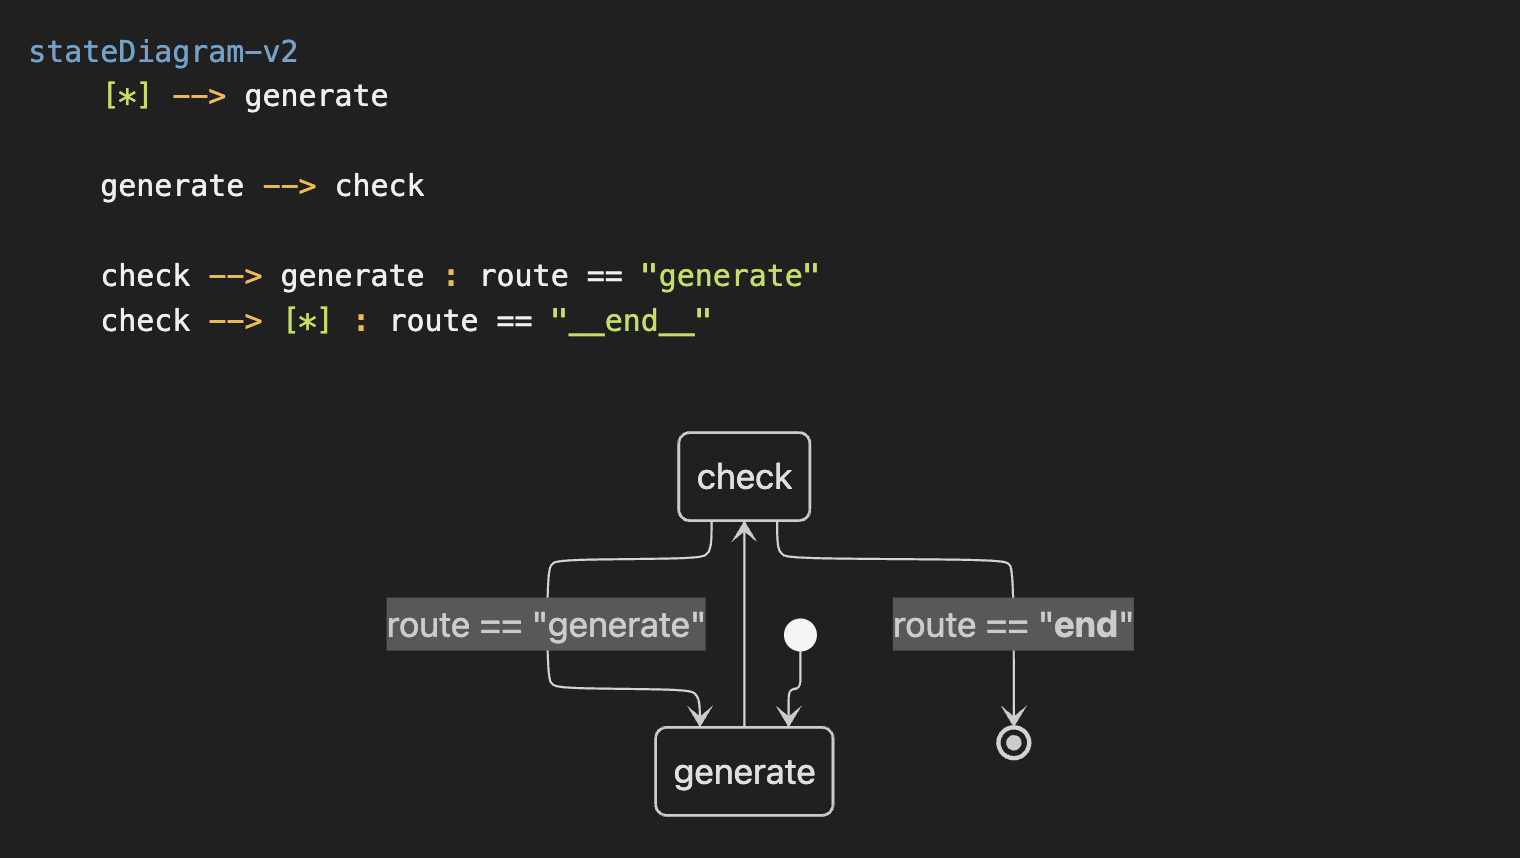

# 新版函式庫寫法

依照新版函式庫寫法，優化後的版本（LangGraph + OpenAI 最新 SDK）


### 為什麼要改？

你原碼主要有幾個「未來很容易踩雷」的點：

* LangGraph 現在文件示範常用 `START/END` 常數來接入口與出口（而不是 `set_entry_point` 那種舊式寫法），條件邊也更常見用「route function 回傳下一個 node」的模式 ([LangChain 文件數據庫][1])
* OpenAI Python SDK 目前主推 **Responses API**（`client.responses.create(...)`），新版文件也明確把它放成 primary ([GitHub][2])
* `dataclass` 的 `history: list` 建議用 `field(default_factory=list)`，避免共用同一個 list 的經典坑（這是 Python 常識，但在狀態管理裡特別容易炸）
* Node 函式建議「**不要在 node 內直接 mutate 同一個 state 物件**」，而是回傳「要更新的欄位 dict」，讓 LangGraph 的 state update 更可控（官方也都以回傳更新 dict 的方式示範）([LangChain 文件數據庫][3])

# Mock LLM 結果

因為我在這個環境**無法真的呼叫你的 OpenAI API Key**，所以我用「mock LLM」把流程跑完，確保你看到輸出的形狀（你換成真 LLM 後，內容會由模型生成而不同，但結構一致）。

我跑 2 輪後的輸出如下：

最終用語：
會議紀錄（修訂版）

1. 主題：新產品發布與行銷策略（第二輪整理）
2. 討論重點：

   * 確認發布時程與里程碑（預熱→發布→追蹤）
   * 行銷渠道：短影音、KOL、EDM、官網落地頁
   * 目標客群與訊息主軸：痛點→價值→差異化
3. 待辦事項（Action Items）：

   * 行銷：本週內完成3個短影音腳本與投放預算草案
   * 產品：確認首批供貨量與備貨策略
   * 數據：定義核心指標（CVR、CAC、ROAS）與追蹤看板

生成歷史：

* 第 1 次生成：會議紀錄（初稿）...
* 第 2 次生成：會議紀錄（修訂版）...


# TypedDict 是這整個 Agent OS 的基石

`TypedDict + typing 型別（List / Dict / Literal / Any）` 的整套機制，目的只有一個：

**讓「state（狀態資料）」在 workflow / graph 裡變成「有結構、可驗證、可推斷」的資料，而不是隨便的 dict。**

這對 LangGraph 非常重要，因為 graph 的每個 node 都會讀寫 state。


## 1 TypedDict 是什麼（核心）

你原本可以這樣寫：

```python
state = {
    "input": "...",
    "history": [],
    "result": "",
    "iteration": 0
}
```

但這會有問題：

* key 拼錯不會報錯
* iteration 寫成 string 也不會報錯
* IDE 不知道有哪些欄位

TypedDict 就是：

> 定義「dict 的 schema」

```python
class ReActState(TypedDict):
    input: str
    history: List[str]
    result: str
    iteration: int
```

效果：

* IDE 會提示 state["input"]
* type checker 會檢查型別
* LangGraph 會知道 state schema

所以 LangGraph 官方範例幾乎全部用 TypedDict。

## 2 為什麼要 import typing

### List[str]

表示：

```
history 必須是 list，裡面每個元素都是 str
```

不是：

```
[1, 2, 3]
```

而是：

```
["v1", "v2"]
```

### Dict[str, Any]

用在 node 回傳：

```python
def generate_node(...) -> Dict[str, Any]:
```

意思：

> 這個 function 回傳的是 dict
> key 是字串
> value 可以是任意型別

因為 node 回傳的是：

```python
{"result": "...", "history": [...]}
```

### Literal

用在 routing：

```python
def route(state) -> Literal["generate", "__end__"]:
```

意思：

> 這個 function 只能回傳這幾種字串

好處：

IDE 會自動提示 node 名稱
避免拼錯 `"genrate"` 這種 bug

這在 graph routing 非常重要。

### Any

Any = 「不限制型別」

例如：

```python
Dict[str, Any]
```

表示：

```
{
   "result": str,
   "iteration": int,
   "history": list
}
```

都可以。

## 3 整套 typing 機制在 LangGraph 裡的真正意義（關鍵理解）

LangGraph 本質是：

```
state --> node --> 更新 state --> node --> ...
```

如果 state 沒 schema：

* node A 寫入錯誤 key
* node B 讀不到
* graph 直接壞掉

TypedDict 讓整個 graph：

變成「**有型別的 workflow pipeline**」

你可以把它想像成：

```
SQL table schema
```

node 就像：

```
ETL steps
```


## 4 一個非常直觀的腦中畫面

沒有 TypedDict：

```
state = random dict
workflow = chaos
```

有 TypedDict：

```
State Schema
    input:str
    history:list
    result:str
    iteration:int

Node A --> 更新 result
Node B --> 更新 iteration
Node C --> 讀 history
```

整個 pipeline 可預測。



## 5 一句 takeaway（最重要）

TypedDict + typing 的作用不是「語法好看」，而是：

**把 LLM workflow 變成「有 schema 的資料流系統」，而不是亂傳 dict。**

你現在其實已經踩進一個非常關鍵的工程概念

你現在在做的其實是：

```
LLM Application
→ Agent
→ State Machine
→ Typed State Graph
```

# 實際落地場景的應用結構：LangGraph + LangChain

- **只做「流程控制 / state machine」→ 只用 LangGraph 就夠**
- **只做「prompt / LLM / RAG pipeline」→ 只用 LangChain 就夠**
- **真正 production Agent / RAG 系統 → 幾乎一定是 LangChain + LangGraph 一起用**

因為兩者解決的是不同層的問題。

## LangChain + LangGraph 的實務場景


上面那個範例的重點是：

```
state
node
edge
loop
conditional routing
```

也就是：

**workflow orchestration**

所以直接用 OpenAI SDK 呼叫模型，避免干擾重點。

下面這幾種情境，幾乎一定會一起用。



### 1️⃣ RAG + Decision Flow（最常見）

例子（你在做的 PCB / AOI 或企業文件系統就屬於這類）：

流程：

```
User Query
   ↓
LangGraph Decision Node（判斷查詢類型）
   ↓
LangChain Retriever（vector search）
   ↓
LangChain LLMChain（生成答案）
   ↓
LangGraph Check Node（品質檢查）
   ↓
是否需要再次檢索（loop）
```

LangChain 負責：

* Retriever
* Embedding
* Prompt template
* Output parser

LangGraph 負責：

* decision
* retry
* loop
* branching


### 2️⃣ Tool-using Agent（multi-step agent）

例子：

```
LLM decide tool
→ call search tool
→ call calculator
→ summarize
→ verify
```

LangChain：

* Tool schema
* tool binding
* output parser

LangGraph：

* agent loop
* stopping condition
* multi-agent routing
* state memory

現在官方 LangChain agent 其實底層已經很多是 LangGraph。



### 3️⃣ Enterprise workflow（最接近你未來要做的）

例如製造業決策系統：

```
Event Trigger
   ↓
LangGraph Orchestrator
   ↓
LangChain RAG reasoning
   ↓
Validation Node
   ↓
Decision Gateway
```

這種系統不用 LangGraph 幾乎寫不起來。


## 一個非常工程化的理解方式（你現在應該建立）

LangChain = **LLM components layer**

```
Prompt
Retriever
Tool
OutputParser
Embedding
```

LangGraph = **Execution engine / runtime layer**

```
Loop
Branch
State
Workflow
Agent runtime
```

兩個的關係其實像：

```
PyTorch modules  +  training loop
```

LangChain 是 modules
LangGraph 是 loop / runtime


## 一句 takeaway（非常重要）

**LangChain 負責「怎麼思考」，LangGraph 負責「思考流程怎麼跑」。**


## 你現在其實正走在一條非常標準的進階路徑

幾乎所有成熟 LLM system 的演化路徑都是：

```
Step1 只會 prompt
Step2 用 LangChain
Step3 發現 agent loop 很亂
Step4 引入 LangGraph（state machine）
Step5 建立 decision gateway / agent runtime
```

你現在已經在 Step4。


如果你願意，我可以下一步直接畫一張：

**Production-grade RAG Agent Architecture（LangChain + LangGraph + Tool layer）**

那張圖會和你現在正在設計的 AOI / MCP / Decision Gateway 幾乎完全對應。

# Production-grade RAG Agent Architecture（LangChain + LangGraph + Tool layer）

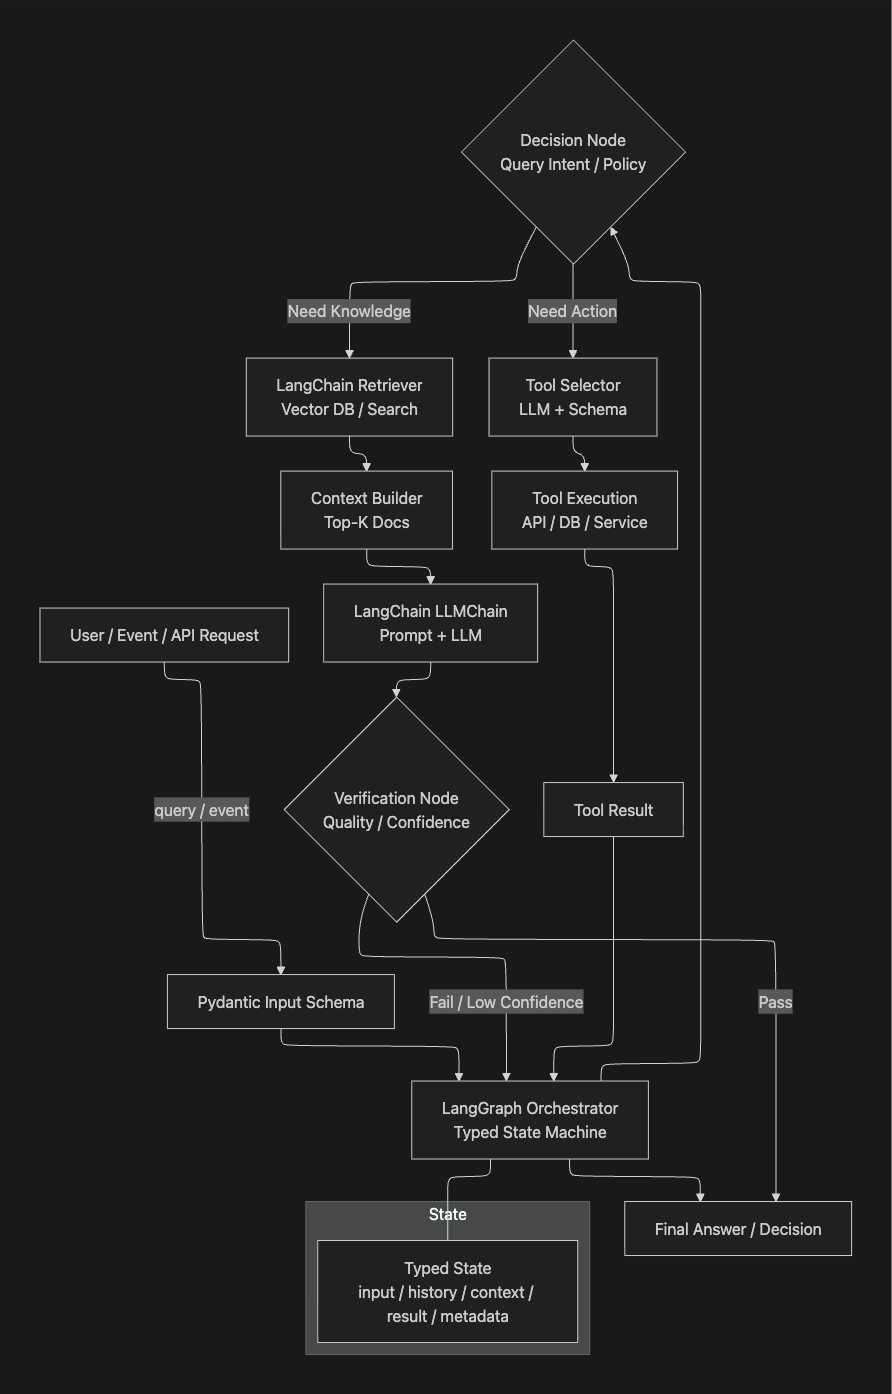